---
title: Introduction to the xcube EOPF Data Store
subtitle: Learn how to build analysis-ready data cubes from multiple EOPF Zarr samples.
authors:
  - name: Konstantin Ntokas
    orcid: 0000-0002-0049-0690
    github: konstntokas
    affiliations:
      - id: Brockmann Consult GmbH
        institution: Brockmann Consult GmbH
        ror: 04r0k9g65
reviewers:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-03-27
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["data access", "xarray", "EOPF Zarr products"]
tags: ["sentinel-2", "xcube", "land"]
releaseDate: 2026-03-27
datePublished: 2026-03-27
dateModified: 2026-03-27
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents
1. [Introduction](#Introduction_XCUBE_EOPF_INTRO)
2. [Install the xcube-eopf Data Store](#Install_XCUBE_EOPF_INTRO)
3. [Introduction to xcube](#Introduction_to_xcube_XCUBE_EOPF_INTRO)
4. [Main Features of the xcube-eopf Data Store](#Main_Features_XCUBE_EOPF_INTRO)
5. [Import modules](#Import_XCUBE_EOPF_INTRO)
6. [Data Store Basics](#Data_store_basics_XCUBE_EOPF_INTRO)
7. [Generating a Data Cube from multiple Samples](#Generation_data_cube_XCUBE_EOPF_INTRO)
8. [Conclusion](#Conclusion_XCUBE_EOPF_INTRO)

(Introduction_XCUBE_EOPF_INTRO)=
## Introduction


`xcube-eopf` is a Python package that extends [xcube](https://xcube.readthedocs.io/en/latest) with a new [data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#available-data-stores) called `"eopf-zarr"`. This plugin enables the creation of analysis-ready data cubes (ARDC) from multiple Sentinel products published by the [EOPF Sentinel Zarr Sample Service](https://zarr.eopf.copernicus.eu/).

This notebook provides an introduction to the xcube EOPF data store, demonstrating its main features and showing initial usage examples. Separate notebooks are available for each EOPF Zarr product collection, showcasing how to access the data and the Sentinel mission specific features used to generate analysis-ready data cubes (ARDCs).

- 🐙 **GitHub:** [EOPF Sample Service – xcube-eopf](https://github.com/EOPF-Sample-Service/xcube-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xcube-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xcube-eopf/)

:::{hint} Overview
**Questions**
- How do I install the xcube-eopf data store?
- How can I use the xcube-eopf data store effectively?
- What main features does the xcube-eopf data store provide?

**Objectives**
- Learn how to open and work with multiple EOPF Sentinel Zarr samples as analysis-ready datacubes (ARDC).
- Understand the key features and capabilities of the xcube EOPF data store.
:::

---

(Install_XCUBE_EOPF_INTRO)=
## Install the xcube EOPF Data Store

The xcube EOPF Data Store can be installed using either `pip` or `conda/mamba` from the conda-forge channel.

- 📦 **PyPI:** [xcube-eopf on PyPI](https://pypi.org/project/xcube-eopf/)  `pip install xcube-eopf`
- 🐍 **Conda (conda-forge):** [xcube-eopf on Anaconda](https://anaconda.org/conda-forge/xcube-eopf) `conda install -c conda-forge xcube-eopf`

You can also use **Mamba** as a faster alternative to Conda: `mamba install -c conda-forge xcube-eopf`

---

(Introduction_to_xcube_XCUBE_EOPF_INTRO)=
## Introduction to xcube

[xcube](https://xcube.readthedocs.io/en/latest/) is an open-source Python toolkit for transforming Earth Observation (EO) data into analysis-ready datacubes following [CF conventions](http://cfconventions.org/cf-conventions/cf-conventions.html). It enables efficient data access, processing, publication, and interactive exploration.

Key components of xcube include:

1. [**xcube data stores**](https://xcube.readthedocs.io/en/latest/dataaccess.html) – efficient access to EO datasets  
2. **xcube data processing** – creation of self-contained analysis-ready datacubes  
3. [**xcube Server**](https://xcube.readthedocs.io/en/latest/webapi.html) – RESTful APIs for managing and serving data cubes  
4. [**xcube Viewer**](https://xcube-dev.github.io/xcube-viewer/build_viewer/#build-and-deploy) – a web app for visualizing and exploring data cubes

### Data Stores

Data stores are implemented as plugins. Once installed, it registers automatically and can be accessed via xcube's `new_data_store()` method. The most important operations of a data store instance `store` are:

- `store.list_data_ids()` - List available data sources.
- `store.has_data(data_id)` - Check data source availability.
- `store.get_open_data_params_schema(data_id)` - View available open parameters for each data source.
- `store.open_data(data_id, **open_params)` - Open a given dataset and return, e.g., an xarray.Dataset instance.

To explore all available functions, see the [Python API](https://eopf-sample-service.github.io/xcube-eopf/api/).

(Main_Features_XCUBE_EOPF_INTRO)=
## Main Features of the xcube-eopf Data Store

The `xcube-eopf` plugin uses the [xarray EOPF backend](https://eopf-sample-service.github.io/xarray-eopf/) to access individual EOPF Zarr samples, then leverages xcube’s data processing capabilities to generate a 3D analysis-ready datacube (ARDCs) from multiple samples.

The workflow for building datacubes from multiple EOPF products involves the following steps, which are implemented in the `open_data()` method:

1. **Query** products using the [EOPF STAC API](https://stac.browser.user.eopf.eodc.eu/) for a given time range and 
   spatial extent.
2. **Retrieve** observations as cloud-optimized Zarr chunks via the [xarray-eopf backend](https://eopf-sample-service.github.io/xarray-eopf/) ([Webinar 3](https://zarr.eopf.copernicus.eu/webinars/webinar-3-access-eopf-zarr-products-with-the-new-xarray-eopf-backend/)).
3. **Mosaic** spatial tiles into single images per timestamp.
4. **Stack** the mosaicked scenes along the temporal axis to form a 3D cube.

📚 **More info:** [xcube-eopf Documentation](https://eopf-sample-service.github.io/xcube-eopf/guide/)

---

(Import_XCUBE_EOPF_INTRO)=
## Import Modules

The `xcube-eopf` data store is provided as a plugin for `xcube`. Once installed, it registers automatically, allowing you to import `xcube` just like any other [xcube data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-access):

In [1]:
import datetime
from xcube.core.store import new_data_store

---

(Data_store_basics_XCUBE_EOPF_INTRO)=
## Data Store Bascis

The following section introduces the basic functionality of an xcube data store. It helps you navigate the store and identify the appropriate parameters for opening datacubes.

To initialize an `eopf-zarr` data store, execute the cell below:

In [2]:
store = new_data_store("eopf-zarr")

The data IDs point to [STAC collections](https://stac.browser.user.eopf.eodc.eu). In the following cell we can list the available data IDs.

In [3]:
store.list_data_ids()

['sentinel-2-l1c',
 'sentinel-2-l2a',
 'sentinel-3-olci-l1-efr',
 'sentinel-3-olci-l2-lfr',
 'sentinel-3-slstr-l1-rbt',
 'sentinel-3-slstr-l2-lst']

One can also check if a data ID is available via the `has_data()` method, as shown below:

In [4]:
store.has_data("sentinel-2-l2a")

True

The Sentinel-5P products are not part of the EOPF Zarr Sample Service, so the following cell returns `False`:

In [5]:
store.has_data("sentinel-5p-l1-ra-bd1-nrti")

False

Below, you can view the parameters for the `open_data()` method for each supported data product. The following cell generates a JSON schema that lists all opening parameters for each supported Sentinel product.

In [6]:
store.get_open_data_params_schema()

This function also shows opening parameters for a specific `data_id`, as shown below. 

In [7]:
store.get_open_data_params_schema(data_id="sentinel-2-l2a")

(Generation_data_cube_XCUBE_EOPF_INTRO)=
## Generating a Data Cube from multiple Samples

We now generate a data cube from the Sentinel-2 L2A product by setting `data_id` to `"sentinel-2-l2a"`. The bounding box is defined to cover the Hamburg area, and the time range is set to the last 15 days. Here, the query parameter is used to select tiles with less than 40% cloud cover, improving the chances of a clear plot. The data cube is requested in the WGS84 (`EPSG:4326`) projection.

In [8]:
ds = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=[9.85, 53.5, 10.05, 53.6],
    time_range=[str(datetime.date.today() - datetime.timedelta(days=15)), None],
    query={"eo:cloud_cover": {"lt": 40}},
    spatial_res=10 / 111320,  # meters converted to degrees (approx.)
    crs="EPSG:4326",
    variables=["b02", "b03", "b04", "scl"],
)
ds

<xarray.Dataset> Size: 124MB
Dimensions:      (time: 2, lon: 2227, lat: 1114)
Coordinates:
  * time         (time) datetime64[s] 16B 2026-03-19T10:35:30 2026-03-22T10:4...
  * lon          (lon) float64 18kB 9.85 9.85 9.85 9.85 ... 10.05 10.05 10.05
  * lat          (lat) float64 9kB 53.6 53.6 53.6 53.6 ... 53.5 53.5 53.5 53.5
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, lat, lon) float64 40MB dask.array<chunksize=(1, 1114, 1830), meta=np.ndarray>
    b03          (time, lat, lon) float64 40MB dask.array<chunksize=(1, 1114, 1830), meta=np.ndarray>
    b04          (time, lat, lon) float64 40MB dask.array<chunksize=(1, 1114, 1830), meta=np.ndarray>
    scl          (time, lat, lon) uint8 5MB dask.array<chunksize=(1, 1114, 1830), meta=np.ndarray>
Attributes: (5)

Note that the 3D datacube generation is fully lazy. The actual data download and processing (e.g. mosaicking, stacking) are performed on demand and only triggered when the data is written or visualized. As an example, we plot a single timestamp in the next cell.

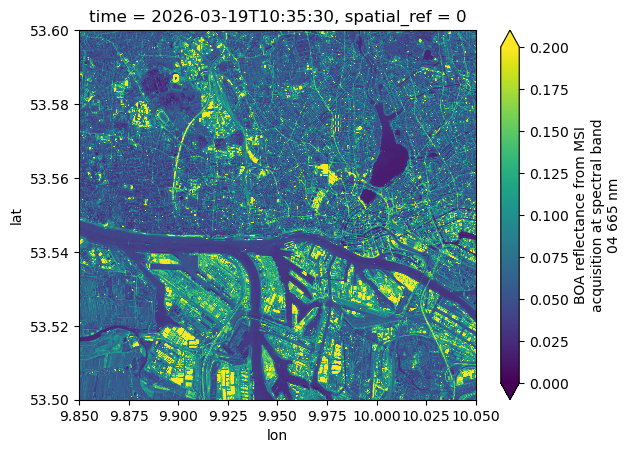

In [9]:
ds.b04.isel(time=0).plot(vmin=0, vmax=0.2)

---

(Conclusion_XCUBE_EOPF_INTRO)=
## Conclusion

This notebook highlighted the main features of the **xcube EOPF Data Store**, which enables seamless access to multiple EOPF Zarr products as **analysis-ready data cubes (ARDCs)**. Key takeaways:

- **3D spatio-temporal analysis-ready data cubes** can be generated from multiple EOPF Sentinel Zarr samples.
- The cube generation workflow follows this pattern:  
  1. **Query** via the [EOPF STAC API](https://stac.browser.user.eopf.eodc.eu/)  
  2. **Read** using the [xarray-eopf backend](https://eopf-sample-service.github.io/xarray-eopf/) ([Webinar 3](https://zarr.eopf.copernicus.eu/webinars/webinar-3-access-eopf-zarr-products-with-the-new-xarray-eopf-backend/))  
  3. **Mosaic** along spatial dimensions  
  4. **Stack** along the temporal dimension  

**Further Examples**

For additional use cases, see the notebooks for **Sentinel-2 and Sentinel-3 EOPF Zarr products**.

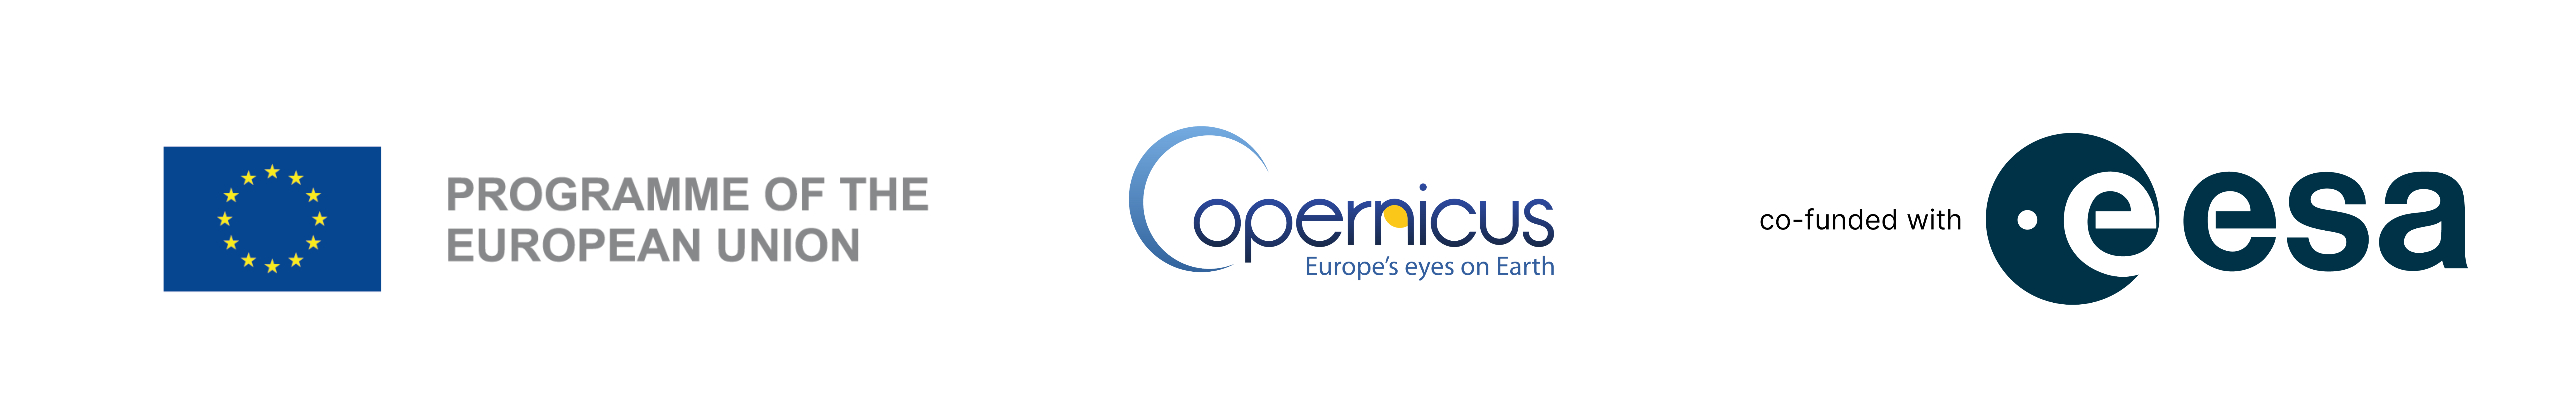